In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [9]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fit.jl")
Main.include("NP.jl")
Main.include("renormalon.jl")

<PyCall.jlwrap renormalon_MS_func>

Range Choice

In [4]:
χ_lower = 115
χ_upper = 165

Read Data

In [6]:
df_OPAL = pd.read_csv("data/OPAL.csv")
truncated_OPAL = df_OPAL[(df_OPAL["CHI"] <= χ_upper) & (df_OPAL["CHI"] >= χ_lower)]

χ_OPAL = np.array(truncated_OPAL["CHI"])
EEC_OPAL = np.array(truncated_OPAL["EEC"])
STAT_OPAL = np.array(truncated_OPAL["STAT"])

print(χ_OPAL.size)

28


Define Minimization

In [7]:
import sys
def objective(params, xlist, ylist, errlist):

    αs = params[0]
    Ω1 = params[1]
    length = len(xlist)

    if len(params) > 2:
        parameters = params[2:]
        residuals = (Main.model(xlist=xlist, αs=αs, parameters=parameters, Ω1=Ω1) - ylist)/errlist #
    else:
        residuals = (Main.model(xlist=xlist, αs=αs, Ω1=Ω1) - ylist)/errlist #

    chi2 = np.sum(np.square(residuals))

    return chi2/length

class ProgressCallback:
    def __init__(self, x_data, y_data, y_err):
        self.x_data = x_data
        self.y_data = y_data
        self.y_err = y_err
        self.iteration = 0
        #self.pbar = tqdm(total=200)

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.x_data, self.y_data, self.y_err)
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()
        #self.pbar.update()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [11]:
objective([0.118,0.1], χ_OPAL, EEC_OPAL, STAT_OPAL)

0.6078065328035328

Global

In [13]:
bounds = [ [0.11  , 0.126]
          ,[0.0  , 0.5]
        # ,[-1.0 , 1.0]
        # ,[-1.0 , 1.0]
        ]

n_points = 9
n_parameters = len(bounds)

points = [np.linspace(bound[0], bound[1], n_points) for bound in bounds]
mesh = np.meshgrid(*points, indexing='ij')
params = [list(coord) for coord in zip(*(x.ravel() for x in mesh))]
print(params)

[[0.11, 0.0], [0.11, 0.1111111111111111], [0.11, 0.2222222222222222], [0.11, 0.3333333333333333], [0.11, 0.4444444444444444], [0.11, 0.5555555555555556], [0.11, 0.6666666666666666], [0.11, 0.7777777777777777], [0.11, 0.8888888888888888], [0.11, 1.0], [0.11177777777777778, 0.0], [0.11177777777777778, 0.1111111111111111], [0.11177777777777778, 0.2222222222222222], [0.11177777777777778, 0.3333333333333333], [0.11177777777777778, 0.4444444444444444], [0.11177777777777778, 0.5555555555555556], [0.11177777777777778, 0.6666666666666666], [0.11177777777777778, 0.7777777777777777], [0.11177777777777778, 0.8888888888888888], [0.11177777777777778, 1.0], [0.11355555555555556, 0.0], [0.11355555555555556, 0.1111111111111111], [0.11355555555555556, 0.2222222222222222], [0.11355555555555556, 0.3333333333333333], [0.11355555555555556, 0.4444444444444444], [0.11355555555555556, 0.5555555555555556], [0.11355555555555556, 0.6666666666666666], [0.11355555555555556, 0.7777777777777777], [0.11355555555555556

In [14]:
chi2_list = []
for parameters in tqdm(params):
    #parameters.insert(0,0.118)
    chi2_list.append(objective(parameters, χ_OPAL, EEC_OPAL, STAT_OPAL))
min_chi2 = min(chi2_list)
best_params = params[chi2_list.index(min_chi2)]
print("min_chi2/dof",min_chi2,"best_params",best_params)

100%|██████████| 100/100 [06:21<00:00,  3.81s/it]

min_chi2/dof 0.7972171907648385 best_params [0.12066666666666667, 0.0]


Local then hopping

In [16]:
initial_params = #best_params #[0.118, 2.0]
bounds = [ [0.110  , 0.126]
          ,[-1.0   , 1.0   ]
        #  ,[0.0   , 10.0  ]
        #  ,[-10.0 , 10.0  ]  
        #  ,[-10.0 , 10.0  ]           
        ]
bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(χ_OPAL, EEC_OPAL, STAT_OPAL)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (χ_OPAL, EEC_OPAL, STAT_OPAL),
    "options": {'maxiter': 100, 'disp': True},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=0,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")

Iteration: 1, Params: [0.12073105 0.01207196], Chi2/dof: 0.7076087930070537
Iteration: 2, Params: [0.12039173 0.02379712], Chi2/dof: 0.6772435663245415
Iteration: 3, Params: [0.11850112 0.08802042], Chi2/dof: 0.5969030125520198
Iteration: 4, Params: [0.11839526 0.09118439], Chi2/dof: 0.5965862008053893
Iteration: 5, Params: [0.11838796 0.09140787], Chi2/dof: 0.5965850024108131
Iteration: 6, Params: [0.11838796 0.09140787], Chi2/dof: 0.5965850024106774
Optimal parameters: [0.11838796 0.09140787]


In [9]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000018f9ae645e0>

Plot

In [71]:
χ_OPAL = np.array(df_OPAL["CHI"])
EEC_OPAL = np.array(df_OPAL["EEC"])
STAT_OPAL = np.array(df_OPAL["STAT"])

In [72]:
xlist = np.pi/180*np.linspace(χ_lower,179.9,100)
length=len(xlist)

αs=optimal_params[0]
Ω1=optimal_params[1]
parameters=[0.0]#optimal_params[1:]

v_2 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, order=2, parameters=parameters, Ω1=Ω1)

non_singular_2 = []

for x in xlist:
    non_singular_2.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

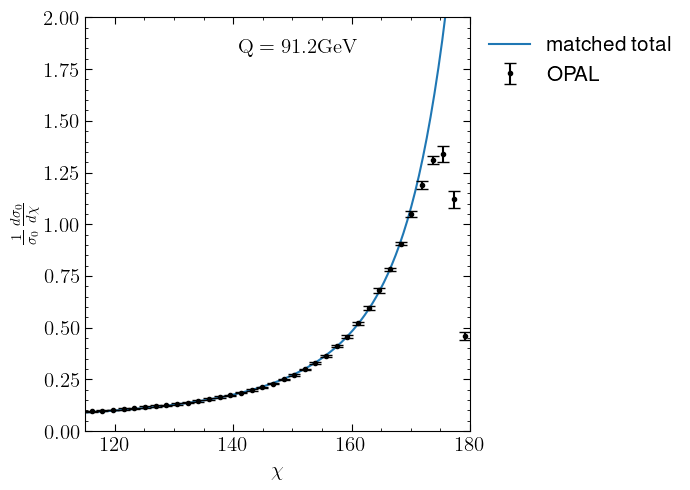

In [78]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_2+non_singular_2, label="matched total")
ax1.errorbar(χ_OPAL, EEC_OPAL, yerr=STAT_OPAL, fmt='o',label="OPAL",color="black", capsize=4,markersize=3)

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,2)
plt.xlim(115,180)

plt.tight_layout()  
plt.show()

In [74]:
non_singular = []
perturbation = []

χ_OPAL_trans = np.pi/180*χ_OPAL
resum = Main.sigma_fast(Q=91.2, χ_list=χ_OPAL_trans, μ_ini=91.1876, αs_ini=αs, nf=5, order=2, Ω1=Ω1)
for x in χ_OPAL_trans:
    non_singular.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=αs, nf=5, order=2)) 
residual = resum + non_singular - EEC_OPAL

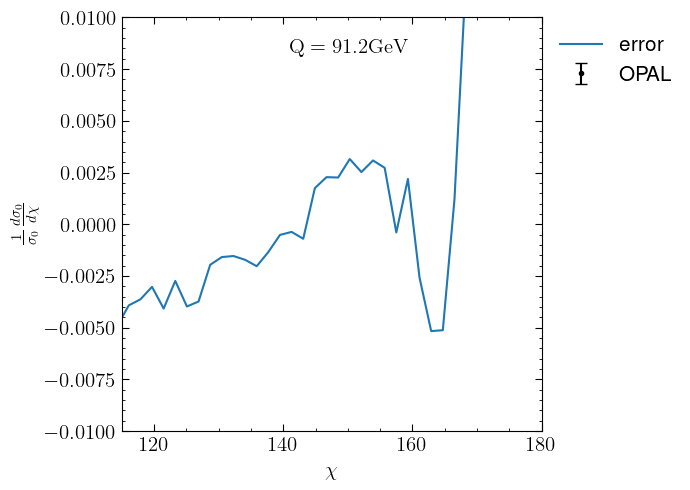

In [76]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.errorbar(χ_OPAL[::2], EEC_OPAL[::2], yerr=STAT_OPAL[::2], fmt='o',label="OPAL",color="black", capsize=4,markersize=3)
ax1.plot(χ_OPAL, residual, label="error")

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(-0.01,0.01)
plt.xlim(115,180)

#plt.xticks([0,30,60,90,120,150,180])
#plt.yticks([0.3,0.6,0.9,1.2,1.5,1.8])

plt.tight_layout()  
plt.show()

In [ ]:
initial_params = [0.118, 2.0]
bounds = [[0.113  , 0.123]
          ,[0.0   , 10.0]]
#          ,[-10.0 , 10.0]
#          ,[-10.0 , 10.0]           
#        ]

progress_callback = ProgressCallback(χ_OPAL, EEC_OPAL, STAT_OPAL)

result = minimize(
    fun=objective,
    x0=initial_params,
    args=(χ_OPAL, EEC_OPAL, STAT_OPAL),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'disp': True},
    #tol = 0.00001,
    callback=progress_callback
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")